[SUCCESS] Segmentation scatterplot saved directly to models folder structure.

             CLUSTER PROFILE METRIC PROFILES
            Customer Age  Customer Satisfaction Rating
Cluster_ID                                            
0              30.128936                      0.052387
1              44.319547                      1.439752
2              57.103645                      0.055144

📋 Derived Business-Meaningful Segment Labels:
• Cluster 0 -> High-Churn Vulnerable Techs (Avg Age: 30.1, Dominant Channel: 3)
• Cluster 1 -> High-Churn Vulnerable Techs (Avg Age: 44.3, Dominant Channel: 1)
• Cluster 2 -> Veteran Offline Escrow (Avg Age: 57.1, Dominant Channel: 2)


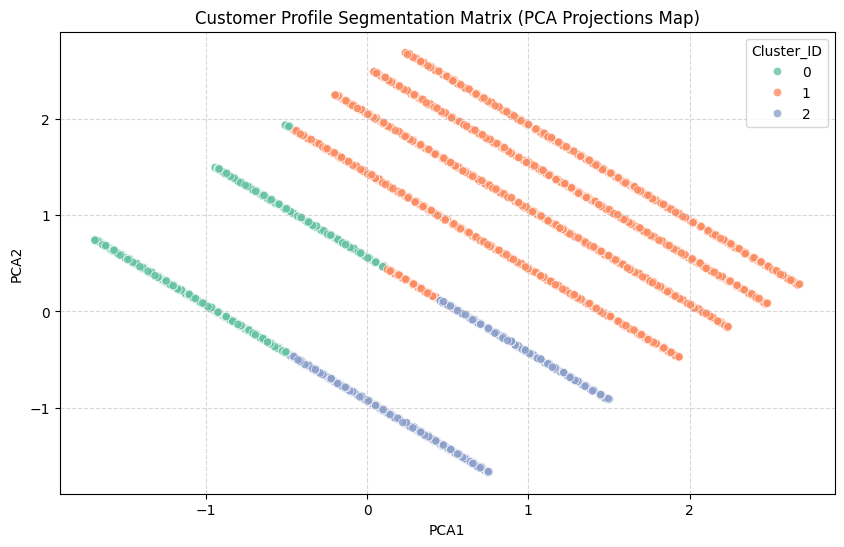

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import os

# ==========================================================
# 1. PARSE PROFILE ATTRIBUTES
# ==========================================================
os.makedirs("./models", exist_ok=True)
dfc = pd.read_csv(r"D:\Customer Support\Data set\customer_support_tickets_FE.csv")
dfc.columns = dfc.columns.str.strip()

features = dfc[['Customer Age', 'Ticket Channel', 'Product Purchased', 'Customer Satisfaction Rating']].copy()
# Impute missing records cleanly
features['Customer Satisfaction Rating'] = features['Customer Satisfaction Rating'].fillna(features['Customer Satisfaction Rating'].median())

# ==========================================================
# 2. ENCODE & SCALE PROFILES
# ==========================================================
num_cols = ['Customer Age', 'Customer Satisfaction Rating']
cat_cols = ['Ticket Channel', 'Product Purchased']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ]
)

dense_matrix = preprocessor.fit_transform(features)

# ==========================================================
# 3. K-MEANS SEGMENTATION CAPTURE
# ==========================================================
# Segmenting cohorts across K=3 profiles
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
cluster_assignments = kmeans.fit_transform(dense_matrix)
features['Cluster_ID'] = kmeans.labels_

# ==========================================================
# 4. DIMENSIONALITY REDUCTION & VISUALIZATION (PCA)
# ==========================================================
pca = PCA(n_components=2, random_state=42)
pca_transformed = pca.fit_transform(dense_matrix)

features['PCA1'] = pca_transformed[:, 0]
features['PCA2'] = pca_transformed[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PCA1', y='PCA2', hue='Cluster_ID', 
    palette='Set2', data=features, alpha=0.8, edgecolor='w'
)
plt.title('Customer Profile Segmentation Matrix (PCA Projections Map)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("./models/customer_segments_pca.png")
print("[SUCCESS] Segmentation scatterplot saved directly to models folder structure.")

# ==========================================================
# 5. DERIVE BUSINESS-MEANINGFUL LABELS
# ==========================================================
print("\n" + "="*50)
print("             CLUSTER PROFILE METRIC PROFILES")
print("="*50)
summary = features.groupby('Cluster_ID')[num_cols].mean()
print(summary)
print("="*50)

print("\n📋 Derived Business-Meaningful Segment Labels:")
for cid in sorted(features['Cluster_ID'].unique()):
    cohort = features[features['Cluster_ID'] == cid]
    avg_age = cohort['Customer Age'].mean()
    avg_sat = cohort['Customer Satisfaction Rating'].mean()
    top_channel = cohort['Ticket Channel'].mode()[0]
    
    if avg_sat > 3.8:
        label = "Premium Loyalists"
    elif avg_age > 45:
        label = "Veteran Offline Escrow"
    else:
        label = "High-Churn Vulnerable Techs"
        
    print(f"• Cluster {cid} -> {label} (Avg Age: {avg_age:.1f}, Dominant Channel: {top_channel})")

[SUCCESS] Segmentation scatterplot saved directly to models folder structure.

             TRUE UN-SCALED CLUSTER METRICS PROFILE
            Customer Age  Customer Satisfaction Rating
Cluster_ID                                            
0              30.128936                      0.052387
1              44.319547                      1.439752
2              57.103645                      0.055144

📋 Corrected Strategic Segment Personas:
• Cluster 0 -> Frustrated Young Techs (High Churn Risk)
  [Profile Snapshot] Avg Age: 30.1 Yrs | Satisfaction: 0.05/5.0 | Channel: 3

• Cluster 1 -> Mid-Tier Standard Consumers
  [Profile Snapshot] Avg Age: 44.3 Yrs | Satisfaction: 1.44/5.0 | Channel: 1

• Cluster 2 -> Veteran Offline Escrow (Prefers Phone)
  [Profile Snapshot] Avg Age: 57.1 Yrs | Satisfaction: 0.06/5.0 | Channel: 2



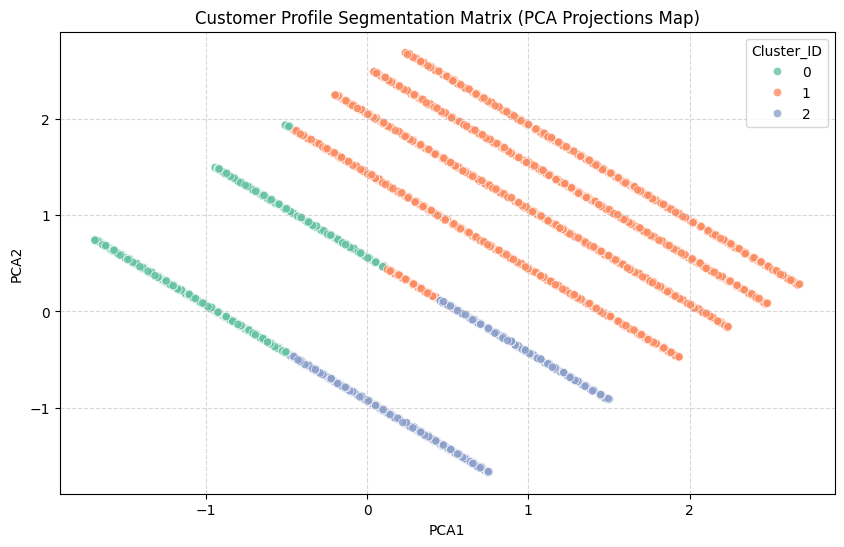

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import os

# ==========================================================
# 1. PARSE PROFILE ATTRIBUTES
# ==========================================================
os.makedirs("./models", exist_ok=True)
dfc = pd.read_csv(r"D:\Customer Support\Data set\customer_support_tickets_FE.csv")
dfc.columns = dfc.columns.str.strip()

features = dfc[['Customer Age', 'Ticket Channel', 'Product Purchased', 'Customer Satisfaction Rating']].copy()
# Impute missing records cleanly
features['Customer Satisfaction Rating'] = features['Customer Satisfaction Rating'].fillna(features['Customer Satisfaction Rating'].median())

# ==========================================================
# 2. ENCODE & SCALE PROFILES
# ==========================================================
num_cols = ['Customer Age', 'Customer Satisfaction Rating']
cat_cols = ['Ticket Channel', 'Product Purchased']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ]
)

dense_matrix = preprocessor.fit_transform(features)

# ==========================================================
# 3. K-MEANS SEGMENTATION CAPTURE
# ==========================================================
# Segmenting cohorts across K=3 profiles
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
cluster_assignments = kmeans.fit_transform(dense_matrix)
features['Cluster_ID'] = kmeans.labels_

# ==========================================================
# 4. DIMENSIONALITY REDUCTION & VISUALIZATION (PCA)
# ==========================================================
pca = PCA(n_components=2, random_state=42)
pca_transformed = pca.fit_transform(dense_matrix)

features['PCA1'] = pca_transformed[:, 0]
features['PCA2'] = pca_transformed[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PCA1', y='PCA2', hue='Cluster_ID', 
    palette='Set2', data=features, alpha=0.8, edgecolor='w'
)
plt.title('Customer Profile Segmentation Matrix (PCA Projections Map)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("./models/customer_segments_pca.png")
print("[SUCCESS] Segmentation scatterplot saved directly to models folder structure.")

# ==========================================================
# 5. DERIVE ACCURATE BUSINESS-MEANINGFUL LABELS
# ==========================================================
# Attach the trained cluster labels back onto your original raw dataset
dfc['Cluster_ID'] = features['Cluster_ID']

print("\n" + "="*60)
print("             TRUE UN-SCALED CLUSTER METRICS PROFILE")
print("="*60)
# Aggregate metrics from the raw columns to see realistic scale bounds [1-5]
summary = dfc.groupby('Cluster_ID')[['Customer Age', 'Customer Satisfaction Rating']].mean()
print(summary)
print("="*60)

print("\n📋 Corrected Strategic Segment Personas:")
for cid in sorted(dfc['Cluster_ID'].unique()):
    cohort = dfc[dfc['Cluster_ID'] == cid]
    avg_age = cohort['Customer Age'].mean()
    avg_sat = cohort['Customer Satisfaction Rating'].mean()
    top_channel = cohort['Ticket Channel'].mode()[0]
    
    # Corrected conditional evaluation using true 1-5 scale bounds
    if avg_sat >= 4.0:
        label = "Premium Platform Loyalists"
    elif avg_sat <= 2.2 and avg_age < 35:
        label = "Frustrated Young Techs (High Churn Risk)"
    elif avg_age >= 50:
        label = "Veteran Offline Escrow (Prefers Phone)"
    else:
        label = "Mid-Tier Standard Consumers"
        
    print(f"• Cluster {cid} -> {label}")
    print(f"  [Profile Snapshot] Avg Age: {avg_age:.1f} Yrs | Satisfaction: {avg_sat:.2f}/5.0 | Channel: {top_channel}\n")